# Tester_branch에서 최종 모델 성능 확인 진행

In [3]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt

wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

wine_df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

wine_df["target"] = wine.target


# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

X = wine_df.drop("target", axis=1)
y = wine_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# DT 모델링 성능

Best Hyper-parameter : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score 0.9224137931034484


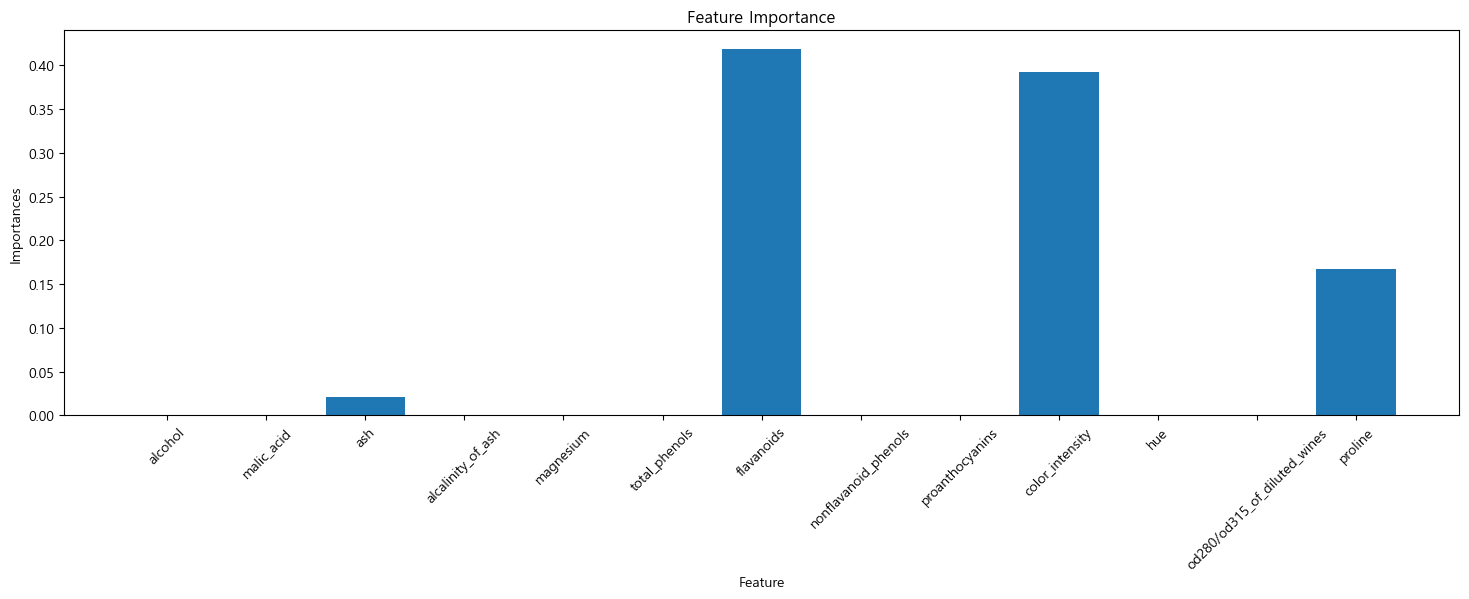

In [9]:
''' 코드를 작성해주세요 '''

# DT 모델링 성능

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6],
    "min_samples_leaf": [1, 2, 3, 4],
    "min_samples_split": [2, 3, 4, 5]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy"
)

dt_grid.fit(X_train, y_train)

dt_model = dt_grid.best_estimator_

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Best Hyper-parameter :", dt_grid.best_params_)
print("Best Score", dt_grid.best_score_)

plt.figure(figsize=(18, 5))

plt.bar(
    X.columns,
    dt_model.feature_importances_
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importances")
plt.xticks(rotation=45)

plt.show()


<img src="../참고이미지/Git/DT_Modeling.png" width="80%">

# XGB 모델링 성능

Best parameters : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
Best accuracy : 0.9645320197044336


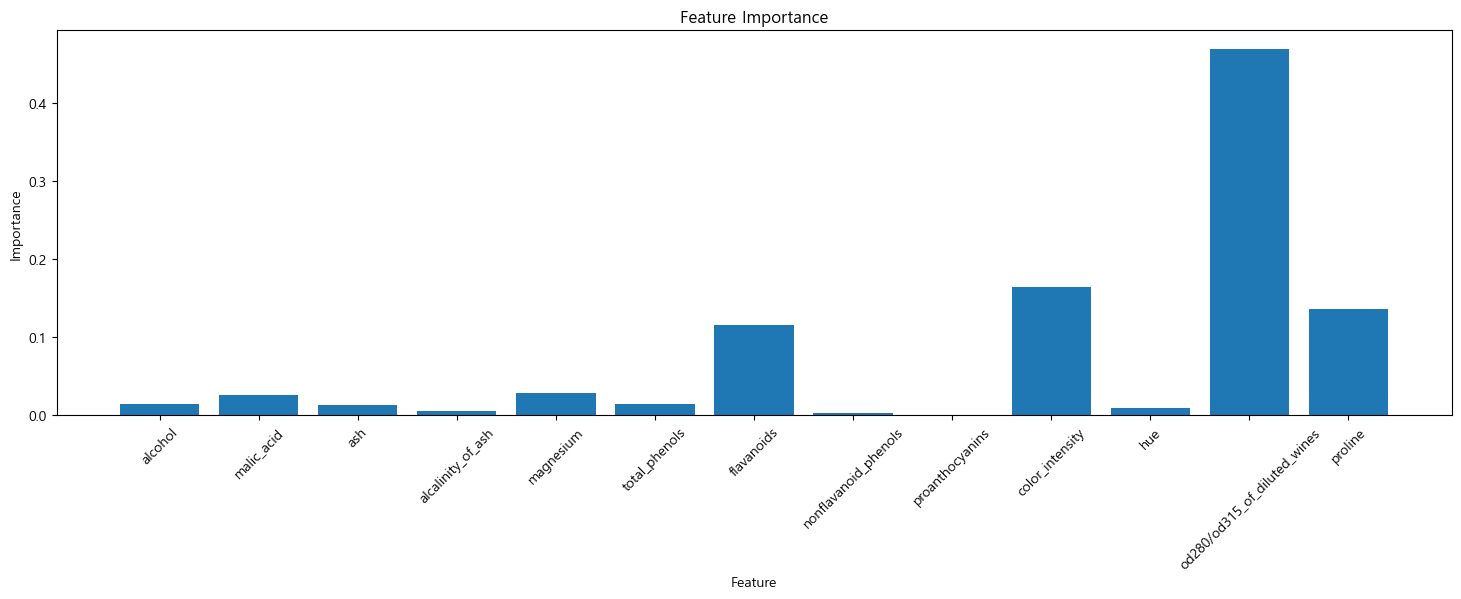

In [10]:
''' 코드를 작성해주세요 '''

# XGB 모델링 성능

from xgboost import XGBClassifier

xgb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "n_estimators": [50, 100, 200]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring="accuracy"
)

xgb_grid.fit(X_train, y_train)

xgb_model = xgb_grid.best_estimator_

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("Best parameters :", xgb_grid.best_params_)
print("Best accuracy :", xgb_grid.best_score_)

plt.figure(figsize=(18, 5))

plt.bar(
    X.columns,
    xgb_model.feature_importances_
)

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()


<img src="../참고이미지/Git/XGB_Modeling.png" width="80%">`

# 성능 비교 시각화

==================== DT 성능 확인 ====================
DT accuracy : 0.9444444444444444
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

==================== XGB 성능 확인 ====================
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



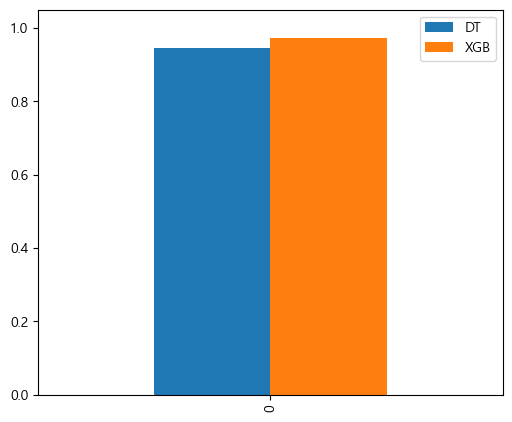

In [11]:
''' 코드를 작성해주세요 '''
print("==================== DT 성능 확인 ====================")
print("DT accuracy :", dt_accuracy)
print(classification_report(y_test, dt_pred))

print("==================== XGB 성능 확인 ====================")
print("XGB accuracy :", xgb_accuracy)
print(classification_report(y_test, xgb_pred))

score_df = pd.DataFrame({
    "DT": [dt_accuracy],
    "XGB": [xgb_accuracy]
})

score_df.plot(
    kind="bar",
    figsize=(6, 5)
)

plt.ylim(0, 1.05)
plt.legend()
plt.show()

<img src="../참고이미지/Git/성능_비교_시각화.png" width="40%">